# Flow Matching with 1D U-Net and On-the-fly Allen-Cahn Data

In [48]:

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

#device = torch.device("cuda" if torch.cuda.is_available() else
                      #"mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else
                      #"cpu")
#print("Using device:", device)


In [49]:

# 1D Allen-Cahn batch simulator (on-the-fly)

def laplacian_1d_batch(u, dx):
    """
    u: (B, N) tensor, periodic BC
    returns: (B, N) tensor of second spatial derivative
    """
    u_left = torch.roll(u, 1, dims=1)
    u_right = torch.roll(u, -1, dims=1)
    return (u_left + u_right - 2*u) / dx**2

def allen_cahn_step_batch(u, eps, dt, dx):
    """
    One Euler step of 1D Allen-Cahn for a batch.

    u:   (B, N)
    eps: (B, 1) or (B,) broadcasting to spatial dim
    """
    lap = laplacian_1d_batch(u, dx)
    nonlinear = u**3 - u
    du_dt = eps**2 * lap - nonlinear
    return u + dt * du_dt

#def allen_cahn_step_batch(u, eps, dt, dx):
#    """
#    Paper version:
#        u_t = u_xx - (1/eps^2) * (u^3 - u)
#    """
#    lap = laplacian_1d_batch(u, dx)
#    nonlinear = u**3 - u
#    du_dt = lap - (1.0 / (eps**2)) * nonlinear
#    return u + dt * du_dt


def simulate_ac_batch(u0, eps, dt, dx, n_steps):
    """
    Simulate Allen-Cahn forward for a batch.

    u0:  (B, N) initial condition
    eps: (B, 1) eps values
    returns: u_T (B, N)
    """
    u = u0
    for _ in range(n_steps):
        u = allen_cahn_step_batch(u, eps, dt, dx)
    return u


In [50]:

# Domain, epsilon sampling, initial conditions, Gaussian blur

# Spatial grid
N = 256
#x = torch.linspace(0., 1., N)
#dx = float(1.0 / (N - 1))
x = torch.linspace(-1., 1., N)
dx = float(2.0 / (N - 1))   # length of interval is now 2

# Time step for AC and number of steps
dt_ac = 1e-3
n_steps_ac = 1000  # can be increased, but this is a good starting point

# Epsilon range (many values)
eps_min, eps_max = 0.002, 0.08


def sample_eps_batch(batch_size):
    """Sample a batch of eps values from [eps_min, eps_max]."""
    eps = torch.empty(batch_size, 1).uniform_(eps_min, eps_max)
    return eps


def ic_analytic_paper(batch_size):
    """Initial condition: u(x,0) = sin(pi x) * x^2 * (1-x)^2."""
    base = 10 * torch.sin(np.pi * x) * x**2 * (1. - x)**2
    return base.unsqueeze(0).repeat(batch_size, 1)  # (B, N)


#def sample_x0_base(batch_size, sigma=1.0):
#    return sigma * torch.randn(batch_size, N)



def sample_x0_bell(batch_size, x, sigma=0.5, center=0.0):
    """
    Returns a FIXED bell-shaped curve for every sample.
    x: tensor (N,) grid in [0,1]
    """
    f = torch.exp(-((x - center)**2) / (2 * sigma**2))  # shape (N,)
    return f.unsqueeze(0).repeat(batch_size, 1)  # shape (B,N)


def make_gaussian_kernel1d(kernel_size=21, sigma=2.0, device=None):
    """Create a 1D Gaussian kernel normalized to sum to 1."""
    if device is None:
        device = torch.device("cpu")
    half = (kernel_size - 1) / 2.
    xs = torch.linspace(-half, half, steps=kernel_size, device=device)
    kernel = torch.exp(-0.5 * (xs / sigma)**2)
    kernel = kernel / kernel.sum()
    return kernel


def gaussian_blur1d(x, kernel):
    """Apply 1D Gaussian blur using a fixed kernel.

    x: (B, N)
    kernel: (K,)
    returns: (B, N)
    """
    B, N = x.shape
    k = kernel.shape[0]
    pad = k // 2
    x_ = x.unsqueeze(1)  # (B,1,N)
    kernel_ = kernel.view(1, 1, -1)  # (1,1,K)
    x_padded = F.pad(x_, (pad, pad), mode="reflect")
    y = F.conv1d(x_padded, kernel_)  # (B,1,N)
    return y.squeeze(1)


gauss_kernel = make_gaussian_kernel1d(kernel_size=21, sigma=2.0)


Sanity check PDE:
u0 range: -12.287911415100098 0.6249688863754272
uT range: -1.0740402936935425 0.902161717414856
eps sample: [0.030939441174268723, 0.046549513936042786, 0.06144198030233383, 0.07706350088119507]


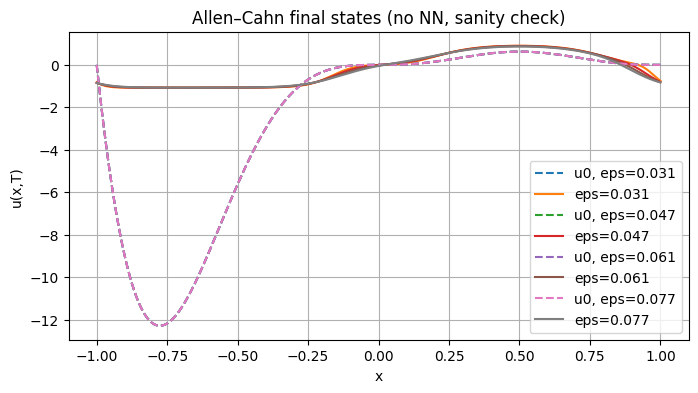

In [51]:
with torch.no_grad():
    B_test = 4
    eps_test = sample_eps_batch(B_test)
    u0_test = ic_analytic_paper(B_test)
    uT_test = simulate_ac_batch(u0_test, eps_test, dt_ac, dx, n_steps_ac)

print("Sanity check PDE:")
print("u0 range:", float(u0_test.min()), float(u0_test.max()))
print("uT range:", float(uT_test.min()), float(uT_test.max()))
print("eps sample:", [float(e.item()) for e in eps_test.view(-1)])

plt.figure(figsize=(8,4))
grid = x.cpu().numpy()
for i in range(B_test):
    plt.plot(grid, u0_test[i].cpu().numpy(), '--', label=f"u0, eps={eps_test[i].item():.3f}")
    plt.plot(grid, uT_test[i].cpu().numpy(), label=f"eps={eps_test[i].item():.3f}")
plt.legend()
plt.title("Allen–Cahn final states (no NN, sanity check)")
plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.grid(True)
plt.show()

In [52]:

# 1D U-Net-like velocity field (no epsilon conditioning)

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, dim),
            nn.SiLU(),
            nn.Linear(dim, dim),
            nn.SiLU(),
        )

    def forward(self, t):
        # t: (B,1)
        return self.net(t)  # (B, dim)


class UNet1D(nn.Module):
    def __init__(self, in_channels=2, base_channels=32, time_dim=64):
        super().__init__()
        self.time_mlp = TimeEmbedding(time_dim)
        self.time_to_bias = nn.Linear(time_dim, base_channels)

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.Conv1d(base_channels, base_channels, kernel_size=5, padding=2),
            nn.SiLU(),
        )
        self.down1 = nn.Conv1d(base_channels, base_channels*2, kernel_size=4, stride=2, padding=1)

        self.enc2 = nn.Sequential(
            nn.Conv1d(base_channels*2, base_channels*2, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.Conv1d(base_channels*2, base_channels*2, kernel_size=5, padding=2),
            nn.SiLU(),
        )
        self.down2 = nn.Conv1d(base_channels*2, base_channels*4, kernel_size=4, stride=2, padding=1)

        # Bottleneck
        self.mid = nn.Sequential(
            nn.Conv1d(base_channels*4, base_channels*4, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.Conv1d(base_channels*4, base_channels*4, kernel_size=5, padding=2),
            nn.SiLU(),
        )

        # Decoder
        self.up1 = nn.ConvTranspose1d(base_channels*4, base_channels*2, kernel_size=4, stride=2, padding=1)
        self.dec1 = nn.Sequential(
            nn.Conv1d(base_channels*4, base_channels*2, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.Conv1d(base_channels*2, base_channels*2, kernel_size=5, padding=2),
            nn.SiLU(),
        )

        self.up2 = nn.ConvTranspose1d(base_channels*2, base_channels, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.Sequential(
            nn.Conv1d(base_channels*2, base_channels, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.Conv1d(base_channels, base_channels, kernel_size=5, padding=2),
            nn.SiLU(),
        )

        self.out_conv = nn.Conv1d(base_channels, 1, kernel_size=3, padding=1)

    def forward(self, x_t, t):
        """
        x_t: (B, N)  current point on the generative path
        t:   (B, 1)  flow time in [0,1]
        returns v_theta(x_t, t): (B, N)
        """
        B, N = x_t.shape

        t_emb = self.time_mlp(t)           # (B, time_dim)
        time_bias = self.time_to_bias(t_emb).unsqueeze(-1)  # (B, base_channels, 1)

        x_in = x_t.unsqueeze(1)            # (B,1,N)
        ones = torch.ones_like(x_in)       # (B,1,N)
        h = torch.cat([x_in, ones], dim=1) # (B,2,N)

        h1 = self.enc1(h)                  # (B, C, N)
        h1 = h1 + time_bias
        d1 = self.down1(h1)                # (B, 2C, N/2)

        h2 = self.enc2(d1)                 # (B, 2C, N/2)
        d2 = self.down2(h2)                # (B, 4C, N/4)

        m = self.mid(d2)                   # (B, 4C, N/4)

        u1 = self.up1(m)                   # (B, 2C, N/2)
        u1 = torch.cat([u1, h2], dim=1)
        u1 = self.dec1(u1)                 # (B, 2C, N/2)

        u2 = self.up2(u1)                  # (B, C, N)
        u2 = torch.cat([u2, h1], dim=1)
        u2 = self.dec2(u2)                 # (B, C, N)

        out = self.out_conv(u2)            # (B,1,N)
        return out.squeeze(1)              # (B,N)


model = UNet1D(in_channels=2, base_channels=32, time_dim=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [53]:

# Generative Flow Matching training (Gaussian smoothing path, on-the-fly AC)

def train_gfm_epoch(model, optimizer, n_batches=50, batch_size=16):
    model.train()
    total_loss = 0.0

    for _ in range(n_batches):
        eps_batch = sample_eps_batch(batch_size)          # (B,1)
        u0_batch = ic_analytic_paper(batch_size)          # (B,N)

        x1 = simulate_ac_batch(u0_batch, eps_batch, dt_ac, dx, n_steps_ac)  # (B,N)

        x0 = sample_x0_bell(batch_size, x)                   # (B,N)


        B = batch_size
        t = torch.rand(B, 1)               # (B,1)

        x1_smooth = gaussian_blur1d(x1, gauss_kernel)     # (B,N)
        x_t = (1.0 - t) * x0 + t * x1_smooth              # (B,N)

        v_target = -x0 + x1_smooth                        # (B,N)

        v_pred = model(x_t, t)                            # (B,N)

        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / n_batches


n_epochs = 50
loss_hist = []

for epoch in range(1, n_epochs + 1):
    avg_loss = train_gfm_epoch(model, optimizer, n_batches=30, batch_size=16)
    loss_hist.append(avg_loss)
    print(f"Epoch {epoch}/{n_epochs} - Loss: {avg_loss:.6f}")


Epoch 1/50 - Loss: 0.591678
Epoch 2/50 - Loss: 0.323820
Epoch 3/50 - Loss: 0.239506
Epoch 4/50 - Loss: 0.105462
Epoch 5/50 - Loss: 0.047037
Epoch 6/50 - Loss: 0.021929
Epoch 7/50 - Loss: 0.014194
Epoch 8/50 - Loss: 0.010327
Epoch 9/50 - Loss: 0.007349
Epoch 10/50 - Loss: 0.007131
Epoch 11/50 - Loss: 0.006532
Epoch 12/50 - Loss: 0.003669
Epoch 13/50 - Loss: 0.003413
Epoch 14/50 - Loss: 0.002544
Epoch 15/50 - Loss: 0.001721
Epoch 16/50 - Loss: 0.001650
Epoch 17/50 - Loss: 0.001841
Epoch 18/50 - Loss: 0.001729
Epoch 19/50 - Loss: 0.001597
Epoch 20/50 - Loss: 0.001369
Epoch 21/50 - Loss: 0.001080
Epoch 22/50 - Loss: 0.001192
Epoch 23/50 - Loss: 0.001192
Epoch 24/50 - Loss: 0.001133
Epoch 25/50 - Loss: 0.001982
Epoch 26/50 - Loss: 0.001458
Epoch 27/50 - Loss: 0.001268
Epoch 28/50 - Loss: 0.001344
Epoch 29/50 - Loss: 0.000855
Epoch 30/50 - Loss: 0.000585
Epoch 31/50 - Loss: 0.000938
Epoch 32/50 - Loss: 0.000894
Epoch 33/50 - Loss: 0.000840
Epoch 34/50 - Loss: 0.000751
Epoch 35/50 - Loss: 0.0

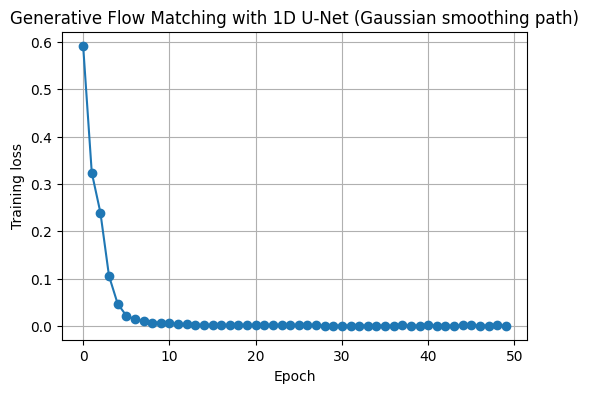

In [54]:

plt.figure(figsize=(6,4))
plt.plot(loss_hist, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Generative Flow Matching with 1D U-Net (Gaussian smoothing path)")
plt.grid(True)
plt.show()


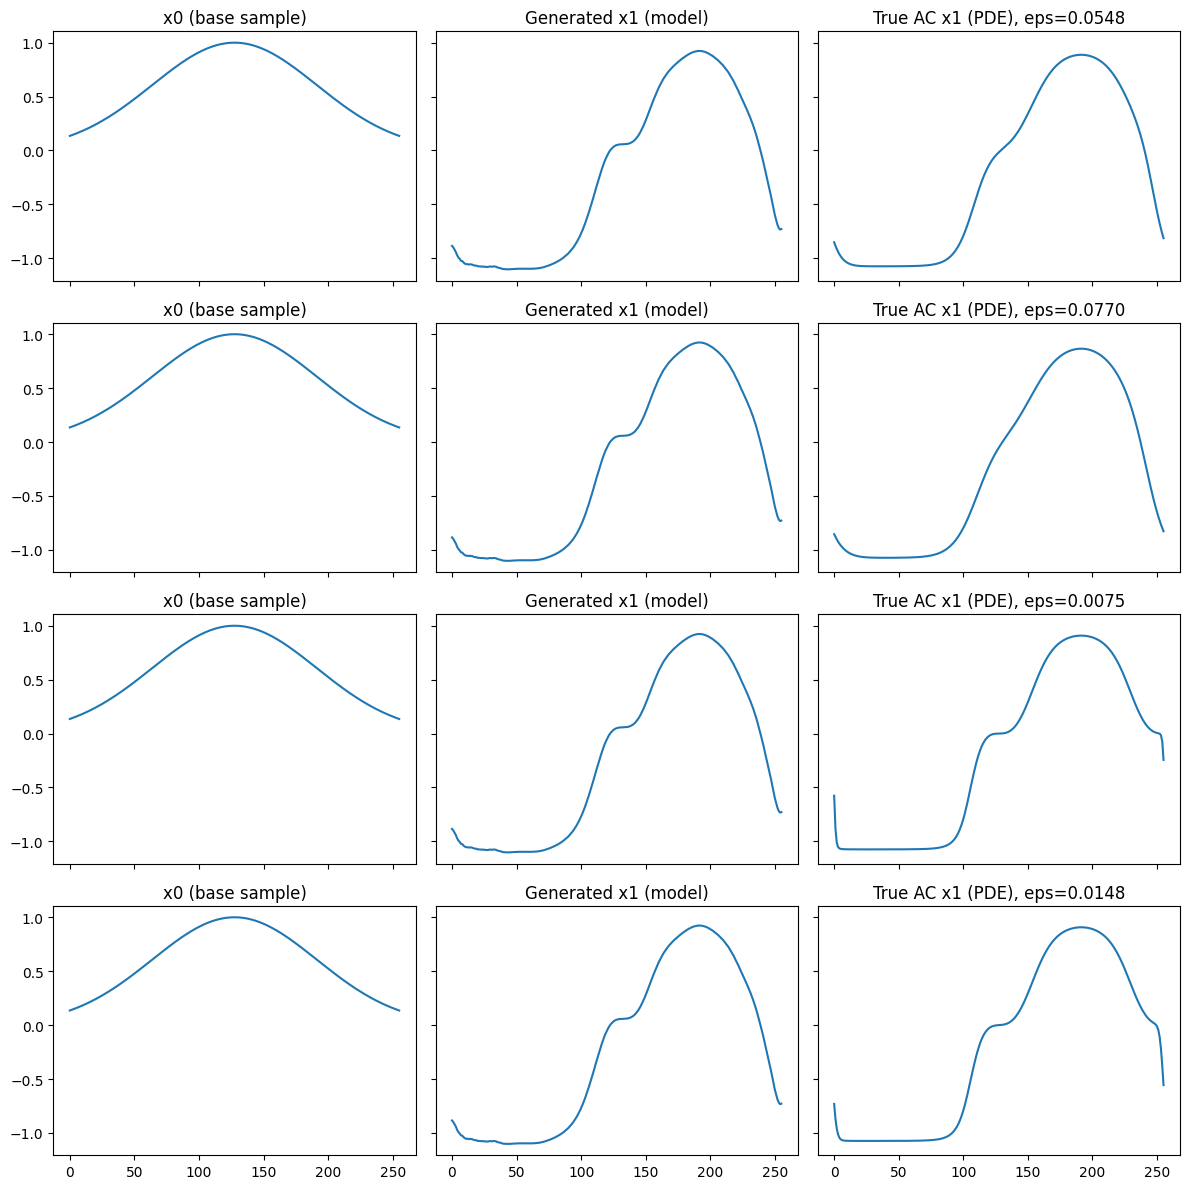

In [55]:

# Sampling from the trained model and comparison to AC

@torch.no_grad()
def sample_from_model(model, x0, n_steps=60):
    """Integrate dx/dt = v_theta(x,t) from t=0 to 1 starting from x0."""
    model.eval()
    B, N = x0.shape
    x = x0.clone()
    ts = torch.linspace(0., 1., n_steps+1)
    dt = ts[1] - ts[0]
    for k in range(n_steps):
        t_mid = 0.5 * (ts[k] + ts[k+1])
        t_batch = t_mid.view(1,1).expand(B,1)
        v = model(x, t_batch)
        x = x + dt * v
    return x.cpu()


B_test = 4
eps_test = sample_eps_batch(B_test)         # (B,1)
u0_test = ic_analytic_paper(B_test)         # (B,N)

x1_true = simulate_ac_batch(u0_test, eps_test, dt_ac, dx, n_steps_ac).cpu()  # (B,N)
x0_test = sample_x0_bell(B_test, x)
x1_gen = sample_from_model(model, x0_test, n_steps=80)


fig, axes = plt.subplots(B_test, 3, figsize=(12, 3*B_test), sharex=True, sharey=True)

for i in range(B_test):
    ax0, ax1, ax2 = axes[i]

    ax0.plot(x0_test[i].cpu().numpy())
    ax0.set_title("x0 (base sample)")

    ax1.plot(x1_gen[i].cpu().numpy())
    #ax1.set_ylim([0.9, 1.2])
    ax1.set_title("Generated x1 (model)")

    ax2.plot(x1_true[i].cpu().numpy())
    #ax2.set_ylim([0.9, 1.2])
    ax2.set_title(f"True AC x1 (PDE), eps={float(eps_test[i].item()):.4f}")

plt.tight_layout()
plt.show()


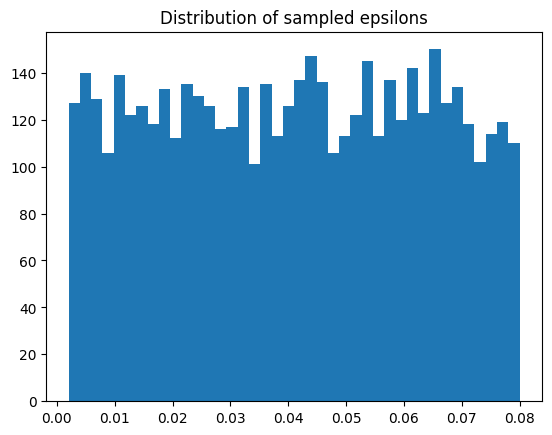

In [56]:
samples = sample_eps_batch(5000).cpu().numpy()
plt.hist(samples, bins=40)
plt.title("Distribution of sampled epsilons")
plt.show()